# 🎙️ OmniASR-CTC-7B — Tunisian Arabic ASR Benchmark

**Model:** facebook/omniASR-CTC-7B  
**Config key:** omniasr_ctc_7B

 > OmniASR uses the omnilingual-asr package (fairseq2-based), NOT HF Transformers.  
 > Inference goes through ASRInferencePipeline with Arabic language tag ara_Arab.  
 > Audio is passed as [{'waveform': array, 'sample_rate': sr}] dicts.  
 > Constraint: segments must be ≤ 40 s; longer audio must be pre-chunked.

## 1 · Install & Imports

In [8]:
# SETUP INSTRUCTIONS FOR LOCAL SERVER
# =====================================
# omnilingual-asr has broken dependencies on PyPI (fairseq2n missing).
# Install manually before running this notebook:
#
# conda create -n omni python=3.10 -y
# conda activate omni
# pip install --no-deps omnilingual-asr
# pip install datasets evaluate jiwer pyyaml torch numpy
# 
# Then select kernel: "Python 3.10 (omni)" and run this notebook.
# ===================================================================

# If packages are already installed, comment out this cell and proceed.
# !pip install -q omnilingual-asr datasets evaluate jiwer pyyaml
# !apt-get install -y -q libsndfile1  # For audio processing on Linux

In [9]:
# Local path to benchmarking package
import sys
from pathlib import Path

BENCHMARK_ROOT = Path('/home/ala/dataset')
assert BENCHMARK_ROOT.exists(), f'Missing path: {BENCHMARK_ROOT}'

if str(BENCHMARK_ROOT) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_ROOT))

print('Using benchmark root:', BENCHMARK_ROOT)

Using benchmark root: /home/ala/dataset


In [10]:
from benchmark_utils import (
    load_config, get_device, print_gpu_info, setup_output_dir,
    load_benchmark, split_benchmark,
    compute_metrics, per_sample_wer,
    run_pipeline_inference, build_results_df,
    run_labelled_splits, run_unlabelled_splits,
    display_preview, display_worst, display_bulk_predictions,
    audio_inspector, display_summary, plot_wer_cer,
)
import numpy as np
import torch
import time
from pathlib import Path
from tqdm.auto import tqdm
from datasets import Audio as HFAudio

cfg = load_config(str(BENCHMARK_ROOT / 'config.yaml'))

# Override Colab-only paths for local execution
cfg['paths']['dataset'] = str(BENCHMARK_ROOT)
cfg['paths']['output_root'] = str(Path('/home/ala/TunisianDialogSystem/outputs/asr_benchmark_results'))

TARGET_SR    = cfg['evaluation']['target_sr']
TOP_N_WORST  = cfg['evaluation']['top_n_worst']
PREVIEW_ROWS = cfg['evaluation']['preview_rows']
RESUME = False

print('Dataset path:', cfg['paths']['dataset'])
print('Output root :', cfg['paths']['output_root'])

Dataset path: /home/ala/dataset
Output root : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results


## 2 · GPU Check

In [11]:
device = get_device()
print_gpu_info()

Device : cuda
GPU    : NVIDIA GB10
VRAM   : 128.5 GB total  |  128.5 GB free


## 3 · Load Model & Pipeline

### 3.1 Load `ASRInferencePipeline` (`omniASR_CTC_7B`)
`ASRInferencePipeline` downloads and caches the model weights on first call.
Pass `model_card` exactly as listed in the omnilingual-asr registry.

| Parameter | Value | Note |
|-----------|-------|--------|
| `model_card` | `omniASR_CTC_7B` | Registry name |  
| `language` | `ara_Arab` | BCP-47 + script |  
| `batch_size` | from config | Tune to GPU VRAM |



In [12]:
!pip install torchaudio retrying

In [13]:
import sys
sys.path.insert(0, '/home/ala/fairseq2/src')
sys.path.insert(0, '/home/ala/fairseq2/native/python/src')

from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline

In [14]:
from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline

mcfg        = cfg['models']['omniasr_ctc_7B']
OUTPUT_DIR  = setup_output_dir(cfg, 'omniasr_ctc_7B')
FILE_SUFFIX = 'omniasr_ctc_7B_results'
BATCH_SIZE  = mcfg['batch_size']
LANG        = mcfg['language']

print("Loading omniASR_CTC_7B ...")
omni_pipe = ASRInferencePipeline(model_card=mcfg['model_card'])
print("✓ omniASR_CTC_7B loaded")

Loading omniASR_CTC_7B ...


Output()

Output()

✓ omniASR_CTC_7B loaded


## 4 · Mount Drive & Load Benchmark

In [15]:
from datasets import DatasetDict, load_from_disk

# Build a DatasetDict from available on-disk split folders only
split_dirs = sorted([p for p in BENCHMARK_ROOT.iterdir() if p.is_dir()])
benchmark = DatasetDict()

for p in split_dirs:
    try:
        benchmark[p.name] = load_from_disk(str(p))
    except Exception:
        pass

print(f"Loaded splits: {list(benchmark.keys())}")
LABELLED_SPLITS, UNLABELLED_SPLITS = split_benchmark(benchmark)

Loaded splits: ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw', 'unlabeled_youtube']
Labelled splits   : ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw']
Unlabelled splits : ['unlabeled_youtube']


## 5 · Inference

In [16]:
!pip install torchcodec

In [17]:
import sys
print(sys.executable)
import torchcodec
print('torchcodec', torchcodec.__version__)
import torch
print('torch', torch.__version__, 'cuda_available=', torch.cuda.is_available())

/home/ala/miniconda3/envs/omni-py310/bin/python
torchcodec 0.11.1+cu130
torch 2.11.0+cu130 cuda_available= True


In [18]:
RESUME = False

# OmniASR hard limit: <= 40 seconds per segment
MAX_ASR_SEC = 40.0
CHUNK_SEC = 39.5  # safety margin
CHUNK_SAMPLES = int(TARGET_SR * CHUNK_SEC)

def _split_audio_for_omniasr(waveform: np.ndarray, sample_rate: int = TARGET_SR):
    """Return a list of ASR input dicts, each <= 40s."""
    if waveform is None or len(waveform) == 0:
        return [{'waveform': np.zeros(1, dtype=np.float32), 'sample_rate': sample_rate}]

    max_allowed = int(MAX_ASR_SEC * sample_rate)
    if len(waveform) <= max_allowed:
        return [{'waveform': waveform.astype(np.float32), 'sample_rate': sample_rate}]

    chunks = []
    for start in range(0, len(waveform), CHUNK_SAMPLES):
        seg = waveform[start:start + CHUNK_SAMPLES]
        if len(seg) == 0:
            continue
        chunks.append({'waveform': seg.astype(np.float32), 'sample_rate': sample_rate})
    return chunks


def infer_fn(ds):
    """
    Wraps ASRInferencePipeline.transcribe().
    Input format: [{'waveform': np.ndarray, 'sample_rate': int}]
    Language tag: 'ara_Arab'.
    Handles OmniASR 40s limit by auto-chunking long audio.
    """
    ds = ds.cast_column('audio', HFAudio(sampling_rate=TARGET_SR))
    predictions, latencies = [], []
    start = time.time()

    for i in tqdm(range(0, len(ds), BATCH_SIZE), desc='Inferring', unit='batch'):
        batch = ds.select(range(i, min(i + BATCH_SIZE, len(ds))))

        # Build per-sample chunk lists
        chunked_per_sample = []
        for x in batch:
            wav = np.array(x['audio']['array'], dtype=np.float32)
            chunked_per_sample.append(_split_audio_for_omniasr(wav, TARGET_SR))

        # Flatten for one transcribe call
        flat_audio_data = [chunk for sample_chunks in chunked_per_sample for chunk in sample_chunks]

        t0 = time.time()
        flat_texts = omni_pipe.transcribe(
            flat_audio_data,
            lang=[LANG] * len(flat_audio_data),
            batch_size=BATCH_SIZE,
        )
        elapsed = time.time() - t0

        # Recompose chunk texts back to one text per original sample
        pos = 0
        for sample_chunks in chunked_per_sample:
            n = len(sample_chunks)
            sample_text = ' '.join(t.strip() for t in flat_texts[pos:pos + n] if isinstance(t, str)).strip()
            predictions.append(sample_text)
            # Keep one latency value per original sample
            latencies.append(elapsed / max(1, len(chunked_per_sample)))
            pos += n

    return predictions, latencies, time.time() - start


all_result_dfs, summary_rows = run_labelled_splits(
    benchmark,
    LABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    PREVIEW_ROWS,
    TOP_N_WORST,
    resume=RESUME,
)


  Running: labeled_algerian  (500 samples)


Inferring:   0%|          | 0/500 [00:00<?, ?batch/s]

  WER              : 0.9819
  CER              : 0.9063
  RTF              : 0.0275
  Total audio      : 3.987 h
  Inference time   : 394.0 s
  Mean latency/smp : 0.7639 s
  Median latency   : 0.7556 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/labeled_algerian_omniasr_ctc_7B_results.csv

  Running: labeled_linagora_cs_arabize  (5482 samples)


Inferring:   0%|          | 0/5482 [00:00<?, ?batch/s]

  WER              : 0.6790
  CER              : 0.3261
  RTF              : 0.0364
  Total audio      : 6.015 h
  Inference time   : 789.1 s
  Mean latency/smp : 0.1400 s
  Median latency   : 0.1276 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/labeled_linagora_cs_arabize_omniasr_ctc_7B_results.csv

  Running: labeled_linagora_raw  (5482 samples)


Inferring:   0%|          | 0/5482 [00:00<?, ?batch/s]

  WER              : 0.6720
  CER              : 0.3470
  RTF              : 0.0363
  Total audio      : 6.015 h
  Inference time   : 786.5 s
  Mean latency/smp : 0.1397 s
  Median latency   : 0.1275 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/labeled_linagora_raw_omniasr_ctc_7B_results.csv

✅ All labelled splits done.


## 6 · Per-sample preview

In [19]:
display_preview(all_result_dfs, PREVIEW_ROWS)


── labeled_algerian ──


,reference,prediction,sample_wer,duration_s
0,في الدار البيضاء ومقاولات كبيرة بسبب الضبابية بسبب هاد الفراغ لي كاين ليوما على مستوى الاقتصاد السياسي واللي دخلنا في الركود التضخمي يعني التضخم دي اقتصادي هابط التراجع ديال النمو والشركات د القطاع الخصوصي الكبيرة كتكمن تقنن النفقات ديالها نقتاسم التوظيف وبالتالي يعني واحد السياسة احترازية,صي ت لف نصاصتويفلالياسزاne,1.000,30.000000
1,في ولا ولا هذا ولا هادشي لي كنت كنقرا وليت راسي كنتوجه الذكاء المالي التطور الشخصي انا دابا انا دابا بديت في التطور الشخصي قريت عليه وبديت كنت كنقرا وبغيت ندير التطور الشخصي ماشي باش نحل مشاكل الناس اللي مجوجين ديالك اه بغيت بغيت التطور الشخصي نخدمو فالتطور,اlcتر الشخصياتور الشخصي ات الشخص المة,0.979,28.650000
2,تكون التجربة ما عندهاش طعم وداك الانتقال من انك دكتور في الجامعة المغربية لأنك مدرب في الجامعة الدولية كي كان هاد الإنتقال وانا انا بديت يعني بديت العمل ديالي في جامعة خارج المغرب سواء في المملكة العربية السعودية وفي الإمارات او في الولايات المتحدة الأمريكية اه ولا كنت في طور يعني ده,نجب عمل م د غ مدرب جمعالدوليبالعمل في جامعة خارج المغرب ملكة العربية السعودية الإماراتويتالمحدالم,0.865,29.250000
3,كاين واحد التعقيد يراد به واحد المجموعة د الأشياء فمن تم يعني درت الدكتوراه في الفين بديت في الفين وتلطاش سنة الفين وتمنطاش ومن تم يعني كذلك يعني طورت القضية ديال الاستشارات المالية التدقيق الشرعي ديال الأيوفي هيئة المراجعة والمحاسبة المعاملات المالية الإسلامية,س ل لم ن تعقيد اد الاالتار ل,1.000,26.600000
4,ديال ديال كل واحد يديها فراسو حسن ليه من المشاكل نديها فراسي ناس جاب نشوف لاخر نشوف راسي انا المصلحة ديالي لا ولا هاد كيقولك اودي المسؤولية ديالهم توقع على الدولة هوما اللي هادي وهادي لا انا كنقول الذي يحرك هاد الرقي الاجتماعي هو منظومة القيم التي نعيشها,ش الي الجعي ايم,1.000,27.350000
5,غير معرفتش واش دابا نضحك ولا نكون معقول لي بغيت كنعرف يعني البرامج ديالك كيكون فيهم بزاف وانا معرفتش نكون المهم هو تعاودلي حكايتي عجبني العنوان شكرا كنهنئك واخا انا عرفت بان شهرزاد ديالي كانت كتحكي لشهر ايار لا بالعكس ماكاين تا مشكل توكلي على الله يالاه ها حنا غانمشيو,ن عض,1.000,28.150000
6,البناء اه بطبيعة الحال را الاعتدال مطلوب يعني ميمكنلناش نتصورو يعني اي بناء اولا توجه نحو التنمية بدون اعتدال لان لا الغلو ويضر والتراخي عاوتاني ايضا الغلو الدفاع مضر والتراخي ايضا مضر وبالتالي ان الاعتدال اساسي حنا المغرب منذ ثلاثة وتسعين والتوجه ديال المغرب في علاقة يعني القطع,ا ا د ا الم ن,1.000,27.650000
7,ديالكم حاولوا ما امكن تاخدوا مية فالمية ها حنا دابا وجدنا الأرض ديالنا اللي غادي ترتاح حتى الوقيتة ديال الربيع اللي خصنا نبداو نغرسوه الحاجة لي مهمة بزاف خصنا لي خصنا ناخدوهم هما الحمد لله دابا ولاو عندنا هاد فالمغرب للأسف مازال ما عندناش لي مية فالمية مغربيين ولكن اه نقدرو نلقاو لي,الباجيكم حل د ة,1.000,27.050000
8,كتخلص رسوم ديال التسجيل والتحفيض الى غير ذلك كتعلم ادارة الضرائب لأن كاين رسوم تسجيل كتأدى تاهو راه بمثابة اعلام واشعار الى غير ذلك ذلك اه اه كدلك خصنا نعلمو السلطة متلا ربما سكن ثانوي ولى سكن رئيسي وخا لأن الضريبة تختلي انا غادي نمشي نعلم فين غادي قلتي الجماعة نعم كاينة الجماعات وكاينة ادارة,ا ل,1.000,30.000000
9,مكاين تا واحد القيمة ديالو شحال غادي طيح تقمارت ولا ماشي تاقمرت معمرو يولي زيرو هدا النفط معمرو يولي زيرو ايجي شي واحد يقولك هادوك ديال ابريل الفين وعشرين كانوا هادوك هداك ماشي البرميل ديال النفط يعني اداة مقامرة او كيهيمنو عل الميدان المالي اليوم مع الأسف,تcrامرود د مر,1.000,27.400000



── labeled_linagora_cs_arabize ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني س ديجا,ق زلت مقتنعة الي اتي تحب تبطل جسبي ه يقعد معايا,1.000,7.776000
1,استفتاء,stifdi,1.000,1.264000
2,يكري كرهبة,يكري كجو,0.500,0.880000
3,عبد الله مشى سال طفلة,啊لل了,1.000,1.528000
4,هاذي غلطتي مش غلطتك,hadi ɣaleḍi mecɣalet,1.000,2.216000
5,بودكاستينق يت ماكس ماي داي على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و ذاي كير اباوت يو و يخمموا معناها,على خاطر فم عبيت تسمع فيك ويهمها اللي تحكي فيه والكل م ويخموا معناها,0.731,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كاس الحومة توا تشوف دنيا كيفاش تتقلب,يطفيو الضوء خليقة تروة إلى الإمارات تهز حتى كأس الحومة توا تشوف الدنيا كيفاش تتقلب,0.467,6.424000
7,عبد الله سال لمرا في القيشي,عبدالله سا اللينرف اليشي,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد الي تبنا كوم آخر الي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كله كوم ها قصر العدالة الجديد اللي تبناء كوم آخر اللي هو خوك زوكربيرج ربي يفضلو بنانها القصر هذيا البلو,0.455,8.712000
9,الي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000



── labeled_linagora_raw ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني c'إي déjà,ق زلت مقتنعة الي اتي تحب تبطل جسبي ه يقعد معايا,1.000,7.776000
1,استفتاء,stifdi,1.000,1.264000
2,يكري كرهبة,يكري كجو,0.500,0.880000
3,عبد الله مشى سأل طفلة,啊لل了,1.000,1.528000
4,هذي غلطتي موش غلطتك,hadi ɣaleḍi mecɣalet,1.000,2.216000
5,podcasting it makes my day على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و they care about you و يخمموا معناها,على خاطر فم عبيت تسمع فيك ويهمها اللي تحكي فيه والكل م ويخموا معناها,0.731,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كأس الحومة توا تشوف دنيا كيفاش تتقلب,يطفيو الضوء خليقة تروة إلى الإمارات تهز حتى كأس الحومة توا تشوف الدنيا كيفاش تتقلب,0.400,6.424000
7,عبد الله سأل لمرا في القيشي,عبدالله سا اللينرف اليشي,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد إلي تبنا كوم آخر إلي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كله كوم ها قصر العدالة الجديد اللي تبناء كوم آخر اللي هو خوك زوكربيرج ربي يفضلو بنانها القصر هذيا البلو,0.455,8.712000
9,إلي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000


## 7 · Worst predictions

In [20]:
display_worst(all_result_dfs, TOP_N_WORST)


── labeled_algerian — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
278,هوما الناس لي راسهم صغير وكيستافدو ومتيقولش ليك واحد الحاجة انا عارف لاحظ هادي هادي لحظة تلاقا مع شي واحد واصل فشي ياك تلاقا مع ماعمر غتجلس نتا وياه وغيقولك لا ما عمرك غتسمع منو وانا عارف ولا هذا الى ريحتي معاه اش كيدير تيريح تيخليك تهضر يالاه ودابا شوف هاد,باش نعترفلك فيه واحد السر لي كنتخبيتو علك ماشحال هدا مننهار تزاديتي وهاد الشريطة ولدي راه ما غادي تسمعو حتى نكون أنا يا مابين الحياة أو الموت ولا غادي تلقاه غير بالصدفة من بعد ما غادي نموت قالت ليها ولدي انت عارف بلي بطبيعة الحال كنبغيك بزاف و انت اعز ولادي وعمري قصرت منجهتك بشي حاجة ولا بخلت عليك بشي حاجة عمري مديتدي عليك ولا خليتك تحتاج لشي حاجة خاص كتعرفها ولدي بلي انت,1.373,29.600000
83,يعطيك الصحة مرة أخرى وثاني للناس هنا معظم متابعينا تقدر تقول عندهم خلفية تقنية لكن كاين ما شاء الله الناس في المجالات متخصصة وحداخرى نحاولو علابيها رانا نحاولو النوعو ثاني المحتوى في هذا الموسم ولي يهتم ثاني بلاك في هذا الموضوع ولكن من ناحية التقنية كاين الحلقة سجلناها مع الأخ,علي الاقل اعطيهم امتيازات اعطيهم حوايج اللي يقدروا يجوك علن بهان المدن داخله باش نقدروا نديروا قطب مليح كامجنو يعودو يجيو يقراو عندنه ع الجلف رجله وشا ونزيد لك كارثه وحد اخري هيتصرا شكمبعد هذي فيال يسمها في اتدرج سمها باش تلحق ماستر بعد المشكله فقالي روحو ادكتورا سما الاشكال ان نهار تلق ناس راحو اللدكتوراه كدير نت جامعه بارتو سما شو الاشكال يودخل فيها المحسوبيه والجهويه,1.320,28.432750
443,و لو يحكي على هاذي القضية تاع أنو دائما هذا النادش شغل دز الإنسان وتحسو بلي هو اتخذ القرار هذاك أقوى بكثير من أنك تقنعو ولا تدلو كيما نقولو حنا صاريلو كما ذوك مش عارف الفيران ذوك تع التجارب لي يديرو لهم حاجة تقيديهم exactement وقادر يهرب منا و منا بصح le faite يشوف حاجة هكذاك تقيديه ي,ولاسد عل الا مولاي تخ لريجامع ااعاس ا دتا تخجت الاعي الجمعيات والانخراض إلى الجمعيات نكون ممثل طلبة سي نونشخيةمليحة وقوية في مجال الطب ولا فيمجال الدراسة ولا يمجالالعمل التطوعي وبعدتخجتأذتمنوجت إلى الصحراء شتغلتفي تمراس في أقصى منطقة في الجزائر بعنغزم فيمتشفكوميلمدة عامين ع تعرف على الجزائر العميقة وأكتشف يعني بلادنا ليمشاللهاعترها قارة وتعرفت على أجناس تت على ثقاات جديدة سمتلي ت التجربة العمل فالصحراء من ن الإنسان ينمي قدرته ن العلمية العمل ت,1.259,106.733750
0,في الدار البيضاء ومقاولات كبيرة بسبب الضبابية بسبب هاد الفراغ لي كاين ليوما على مستوى الاقتصاد السياسي واللي دخلنا في الركود التضخمي يعني التضخم دي اقتصادي هابط التراجع ديال النمو والشركات د القطاع الخصوصي الكبيرة كتكمن تقنن النفقات ديالها نقتاسم التوظيف وبالتالي يعني واحد السياسة احترازية,صي ت لف نصاصتويفلالياسزاne,1.000,30.000000
3,كاين واحد التعقيد يراد به واحد المجموعة د الأشياء فمن تم يعني درت الدكتوراه في الفين بديت في الفين وتلطاش سنة الفين وتمنطاش ومن تم يعني كذلك يعني طورت القضية ديال الاستشارات المالية التدقيق الشرعي ديال الأيوفي هيئة المراجعة والمحاسبة المعاملات المالية الإسلامية,س ل لم ن تعقيد اد الاالتار ل,1.000,26.600000
4,ديال ديال كل واحد يديها فراسو حسن ليه من المشاكل نديها فراسي ناس جاب نشوف لاخر نشوف راسي انا المصلحة ديالي لا ولا هاد كيقولك اودي المسؤولية ديالهم توقع على الدولة هوما اللي هادي وهادي لا انا كنقول الذي يحرك هاد الرقي الاجتماعي هو منظومة القيم التي نعيشها,ش الي الجعي ايم,1.000,27.350000
5,غير معرفتش واش دابا نضحك ولا نكون معقول لي بغيت كنعرف يعني البرامج ديالك كيكون فيهم بزاف وانا معرفتش نكون المهم هو تعاودلي حكايتي عجبني العنوان شكرا كنهنئك واخا انا عرفت بان شهرزاد ديالي كانت كتحكي لشهر ايار لا بالعكس ماكاين تا مشكل توكلي على الله يالاه ها حنا غانمشيو,ن عض,1.000,28.150000
6,البناء اه بطبيعة الحال را الاعتدال مطلوب يعني ميمكنلناش نتصورو يعني اي بناء اولا توجه نحو التنمية بدون اعتدال لان لا الغلو ويضر والتراخي عاوتاني ايضا الغلو الدفاع مضر والتراخي ايضا مضر وبالتالي ان الاعتدال اساسي حنا المغرب منذ ثلاثة وتسعين والتوجه ديال المغرب في علاقة يعني القطع,ا ا د ا الم ن,1.000,27.650000
7,ديالكم حاولوا ما امكن تاخدوا مية فالمية ها حنا دابا وجدنا الأرض ديالنا اللي غادي ترتاح حتى الوقيتة ديال الربيع اللي خصنا نبداو نغرسوه الحاجة لي مهمة بزاف خصنا لي خصنا ناخدوهم هما الحمد لله دابا ولاو عندنا هاد فالمغرب للأسف مازال ما عندناش لي مية فالمية مغربيين ولكن اه نقدرو نلقاو لي,الباجيكم حل د ة,1.000,27.050000
8,كتخلص رسوم ديال التس


── labeled_linagora_cs_arabize — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
2129,سبعمياة,ça va u mié,4.000,1.376000
3040,نرمالمن سنسي يقراو امم,لله تسلفة ت م الحضائر متعرضين للمدرسة نعطيك معه في بودرس في جاسرين للآن مسكر بالحجر,4.000,10.672000
1572,يعيشك,eeeeeeeeeee eeeee ae,3.000,4.306000
3178,باهي ايه ترى بيان,-ترك و عنات بينا صحاب طخمو أياأنا شدي تروحي نهار دروحك نهارين,3.000,4.280000
25,يقري,ا خاري,2.000,0.864000
193,مهني,مي هادي,2.000,0.848000
635,مشحاح,مش حاح,2.000,0.920000
1454,الترموماتر,e termometër,2.000,1.464000
1464,القبرص,al قobros,2.000,1.256000
1502,الحساسية,ان حساسية,2.000,1.712000



── labeled_linagora_raw — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
2129,سبعمياة,ça va u mié,4.000,1.376000
3040,نرمالمن سنسي يقراو إمم,لله تسلفة ت م الحضائر متعرضين للمدرسة نعطيك معه في بودرس في جاسرين للآن مسكر بالحجر,4.000,10.672000
1572,يعيشك,eeeeeeeeeee eeeee ae,3.000,4.306000
3178,باهي أيه ترى بيان,-ترك و عنات بينا صحاب طخمو أياأنا شدي تروحي نهار دروحك نهارين,3.000,4.280000
25,يقري,ا خاري,2.000,0.864000
193,مهني,مي هادي,2.000,0.848000
635,مشحاح,مش حاح,2.000,0.920000
1454,الترموماتر,e termometër,2.000,1.464000
1464,القبرص,al قobros,2.000,1.256000
1502,الحساسية,ان حساسية,2.000,1.712000


## 8 · Unlabelled inspection

In [21]:
unlabelled_result_dfs = run_unlabelled_splits(
    benchmark,
    UNLABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    resume=RESUME,
)


  Running (unlabelled): unlabeled_youtube  (398 samples)


Inferring:   0%|          | 0/398 [00:00<?, ?batch/s]

  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/unlabeled_youtube_omniasr_ctc_7B_results.csv

✅ All unlabelled splits done.


In [22]:
display_bulk_predictions(unlabelled_result_dfs)


── unlabeled_youtube — all 398 predictions ──


,prediction,duration_s,audio_id,source_url,seg_start,seg_end
0,إدارة الصيدلة والأدوية بوزارة الصحة تقرر سحب أربعة مكملات غذائية من السوق لعدم تطابقها مع المواصفات خبر قد يعتبر في ظاهره عاديا لكنه يخفي مشاكل كبرى تتعلق ا,14.976000,MDU2ROgeKns_0,https://www.youtube.com/watch?v=MDU2ROgeKns,0.000000,15.000000
1,فهذه المواد نجدها معروضة في مسالك اخرى غير الصيدليات حيث انها تباع ويروج لها عبر الانترنت ومواقع التواصل الاجتماعي,15.000000,MDU2ROgeKns_1,https://www.youtube.com/watch?v=MDU2ROgeKns,15.000000,30.000000
2,تالغذائية تبقى المواقع الواب اللي هما يبيعوا في الأشياء هذي في الحقيقة أنا ما ندورش بيهم كنت نشري الحق ل يضهرلي حاجة بييا ما فع توك ل لوزارة كيما قال منعتو م نعتو مام,15.000000,MDU2ROgeKns_2,https://www.youtube.com/watch?v=MDU2ROgeKns,30.000000,45.000000
3,ا منش معرضين اشي هذا لشكال نتاع المكملات الغذائية للي مصنوعة في تونس اللى نجمو نلق في الصيدريات ولا نجم نلق في اي موقع تجاري اخر ولا حتى في مواقع التواصل الاجتماعي ولا على الانترنت م شال بير فامكملات الغذائي,15.000000,MDU2ROgeKns_3,https://www.youtube.com/watch?v=MDU2ROgeKns,45.000000,60.000000
4,محلية اللي جودة متاعهم تنجم في بعض الحالات ما يكونوش جيدين المصنعين محلين ما يخضعولحتى قانون ونلاحظو اللى برشا موجهين الاطفال وهذاي يختر صافي على الصحت الصغار اليوم عنا هذوما اللي صاحبتهم ز,15.000000,MDU2ROgeKns_4,https://www.youtube.com/watch?v=MDU2ROgeKns,60.000000,75.000000
5,لكن زاد فم فيريانا زاد اكتشفوا الى فم محل غير مؤهل لصناعة المواد هذي وقاعد يصنع فيبعض الحاجات اللي هي موجهة خاصة الاطفال,14.896000,MDU2ROgeKns_5,https://www.youtube.com/watch?v=MDU2ROgeKns,75.000000,90.000000
6,ا تشكيات من عديد المواطنين تعرضوا لعمليات تحيل عند اقتناء مكملات غذائية من مواقع الإنترنت في وقت تطالب خلاله نقابة أصحاب الصيدليات الخاصة وزارة الصحة بتفعيل القانون المنظم لهذا القطاع,14.840000,MDU2ROgeKns_6,https://www.youtube.com/watch?v=MDU2ROgeKns,90.000000,105.000000
7,اليوم القانون موجود في رفوف وزارة الصحة ما صدرش القانون هذايا هو أمر حكومي الأمر الحكومي هذايا متفق عليه من طرف جميع مالداخلين في القطاع ما فهمناش علاش لتو ما خرجش أمر لحكومي ذايا في غياب القانو فمغيابلمخالفا,14.904000,MDU2ROgeKns_7,https://www.youtube.com/watch?v=MDU2ROgeKns,105.000000,120.000000
8,وغياب لمراقب دوك اليوم متجم تعملهم حتى شي حتى في الصنع والا في التوزيع المكملات الغذائية صحيح هي معناها باهيه لكن ماذا بينا زاد ناخذو نصيحة الطبيب المباشر متاعنا قب اقبال علي المواد هذيا,14.992000,MDU2ROgeKns_8,https://www.youtube.com/watch?v=MDU2ROgeKns,120.000000,135.000000
9,و ناكد و ناكد هنا و نعاود قديش احنا كمنظمة تشكيات جك منظمة شكيات من على اساس وقع اقتنا على اساس مكاملات غذائية وكانت مواد تثبت في برشه مشاكل صحية هني دعوة الى,15.000000,MDU2ROgeKns_9,https://www.youtube.com/watch?v=MDU2ROgeKns,135.000000,150.000000


## 9 · Summary

In [23]:
summary_df = display_summary(
    summary_rows, OUTPUT_DIR, 'omniasr_ctc_7B', 'omniasr_ctc_7B_results'
)

,dataset,n_samples,total_audio_h,WER,CER,RTF,inference_time_s,mean_latency_s,median_latency_s
0,labeled_algerian,500,3.987,0.9819,0.9063,0.0275,394.0,0.7639,0.7556
1,labeled_linagora_cs_arabize,5482,6.015,0.6790,0.3261,0.0364,789.1,0.1400,0.1276
2,labeled_linagora_raw,5482,6.015,0.6720,0.3470,0.0363,786.5,0.1397,0.1275



✓ Summary saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/omniasr_ctc_7B_benchmark_summary.csv

--------------------------------------------------
  Macro-avg WER : 0.7776
  Macro-avg CER : 0.5265
  Total audio   : 16.017 h
  Output dir    : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results


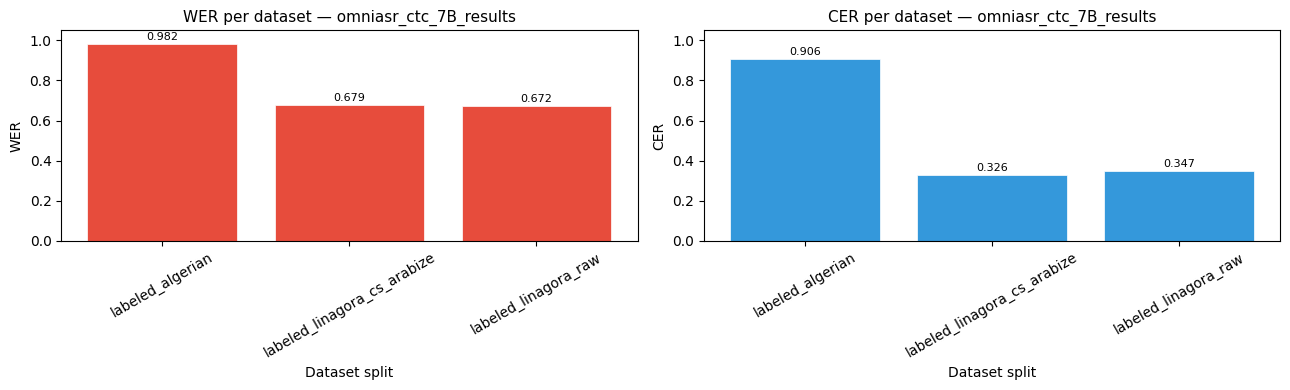

✓ Chart saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_7B_results/omniasr_ctc_7B_wer_cer_chart.png


In [24]:
if summary_df is not None:
    plot_wer_cer(summary_df, OUTPUT_DIR, 'omniasr_ctc_7B', 'omniasr_ctc_7B_results')